In [1]:
req.libs <- c("data.table", "dplyr", "ggplot2", "scattermore", 
              "stringi", "tidyr", "viridis", "Matrix", "tibble", "ComplexHeatmap", "circlize")
lapply(req.libs, function(x){
    suppressMessages(library(x, character.only = TRUE))})

[[1]]
[1] "data.table" "stats"      "graphics"   "grDevices"  "utils"     
[6] "datasets"   "methods"    "base"      

[[2]]
[1] "dplyr"      "data.table" "stats"      "graphics"   "grDevices" 
[6] "utils"      "datasets"   "methods"    "base"      

[[3]]
 [1] "ggplot2"    "dplyr"      "data.table" "stats"      "graphics"  
 [6] "grDevices"  "utils"      "datasets"   "methods"    "base"      

[[4]]
 [1] "scattermore" "ggplot2"     "dplyr"       "data.table"  "stats"      
 [6] "graphics"    "grDevices"   "utils"       "datasets"    "methods"    
[11] "base"       

[[5]]
 [1] "stringi"     "scattermore" "ggplot2"     "dplyr"       "data.table" 
 [6] "stats"       "graphics"    "grDevices"   "utils"       "datasets"   
[11] "methods"     "base"       

[[6]]
 [1] "tidyr"       "stringi"     "scattermore" "ggplot2"     "dplyr"      
 [6] "data.table"  "stats"       "graphics"    "grDevices"   "utils"      
[11] "datasets"    "methods"     "base"       

[[7]]
 [1] "viridis"     "viridisLite" "tidyr"       "stringi"     "scattermore"
 [6] "ggplot2"     "dplyr"       "data.table"  "stats"       "graphics"   
[11] "grDevices"   "utils"       "datasets"    "methods"     "base"       

[[8]]
 [1] "Matrix"      "viridis"     "viridisLite" "tidyr"       "stringi"    
 [6] "scattermore" "ggplot2"     "dplyr"       "data.table"  "stats"      
[11] "graphics"    "grDevices"   "utils"       "datasets"    "methods"    
[16] "base"       

[[9]]
 [1] "tibble"      "Matrix"      "viridis"     "viridisLite" "tidyr"      
 [6] "stringi"     "scattermore" "ggplot2"     "dplyr"       "data.table" 
[11] "stats"       "graphics"    "grDevices"   "utils"       "datasets"   
[16] "methods"     "base"       

[[10]]
 [1] "ComplexHeatmap" "grid"           "tibble"         "Matrix"        
 [5] "viridis"        "viridisLite"    "tidyr"          "stringi"       
 [9] "scattermore"    "ggplot2"        "dplyr"          "data.table"    
[13] "stats"          "graphics"       "grDevices"      "utils"         
[17] "datasets"       "methods"        "base"          

[[11]]
 [1] "circlize"       "ComplexHeatmap" "grid"           "tibble"        
 [5] "Matrix"         "viridis"        "viridisLite"    "tidyr"         
 [9] "stringi"        "scattermore"    "ggplot2"        "dplyr"         
[13] "data.table"     "stats"          "graphics"       "grDevices"     
[17] "utils"          "datasets"       "methods"        "base"

In [232]:
meta <- fread("/mnt/users/rachelsavage/paper_minimorf/data/initial_filtering/atac.filtered.metadata.tsv")
donor.info <- fread("/mnt/users/rachelsavage/paper_minimorf/data/donor_calling/filt.donor.txt")
bam.dir <- "/fab/AlignedData/rsav_minimorf/ruochi_temp_barcode_align"
bam.inputs <- list.files(bam.dir, full.names = TRUE, pattern = ".bam$",)

In [233]:
bam.input <- "/fab/AlignedData/rsav_minimorf/ruochi_temp_barcode_align/BUENSS322-96-ENTIRE-PLATE.Aligned.sortedByCoord.out.bam"

In [235]:
# pkr 624 == buenss322
cmd <- "samtools view -F 256 /fab/AlignedData/rsav_minimorf/ruochi_temp_barcode_align/BUENSS322-96-ENTIRE-PLATE.Aligned.sortedByCoord.out.bam | awk '{print $1, $2, $3, $4, $5, $12, $13, $16, $18}'"
df <- fread(cmd = cmd, header = FALSE, stringsAsFactors = FALSE) 

In [236]:
setnames(df, c("Read_Name", "Strand", "Alignment", "Alignment_Position", "MAPQ", "Cellbc", "UMI", "n.alignments", "alignment.score"))
df[, n.alignments := sub("^NH:i:", "", n.alignments)]
df[, alignment.score := sub("^AS:i:", "", alignment.score)]
df[, UMI := sub("^UR:Z:", "", UMI)]

We're gonna set some cutoffs. We want only reads that align to one location. And we want reads that have a good alignment score. 

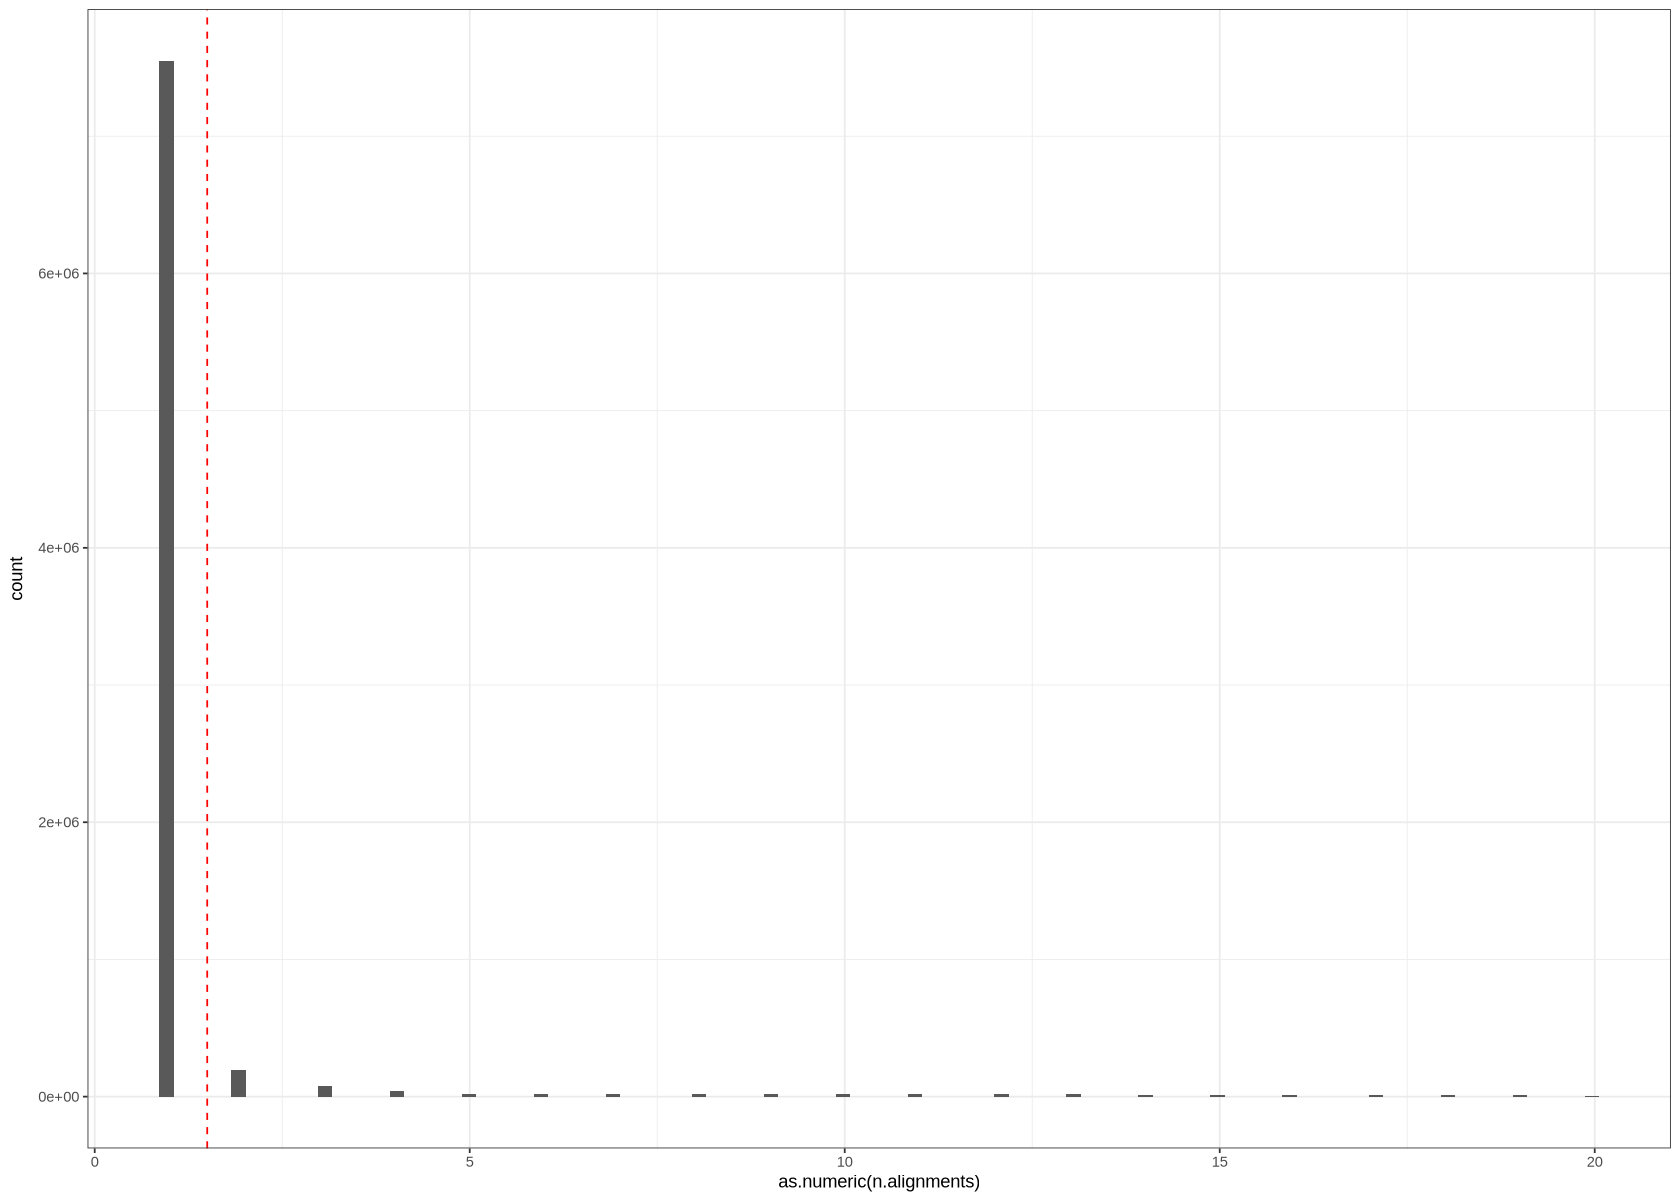

In [38]:
n.alignment.cutoff <- 1.5

ggplot(df, aes(x=as.numeric(n.alignments)))+
geom_histogram(bins = 100)+
geom_vline(xintercept = n.alignment.cutoff, linetype = "dashed", color = "red")+
theme_bw()

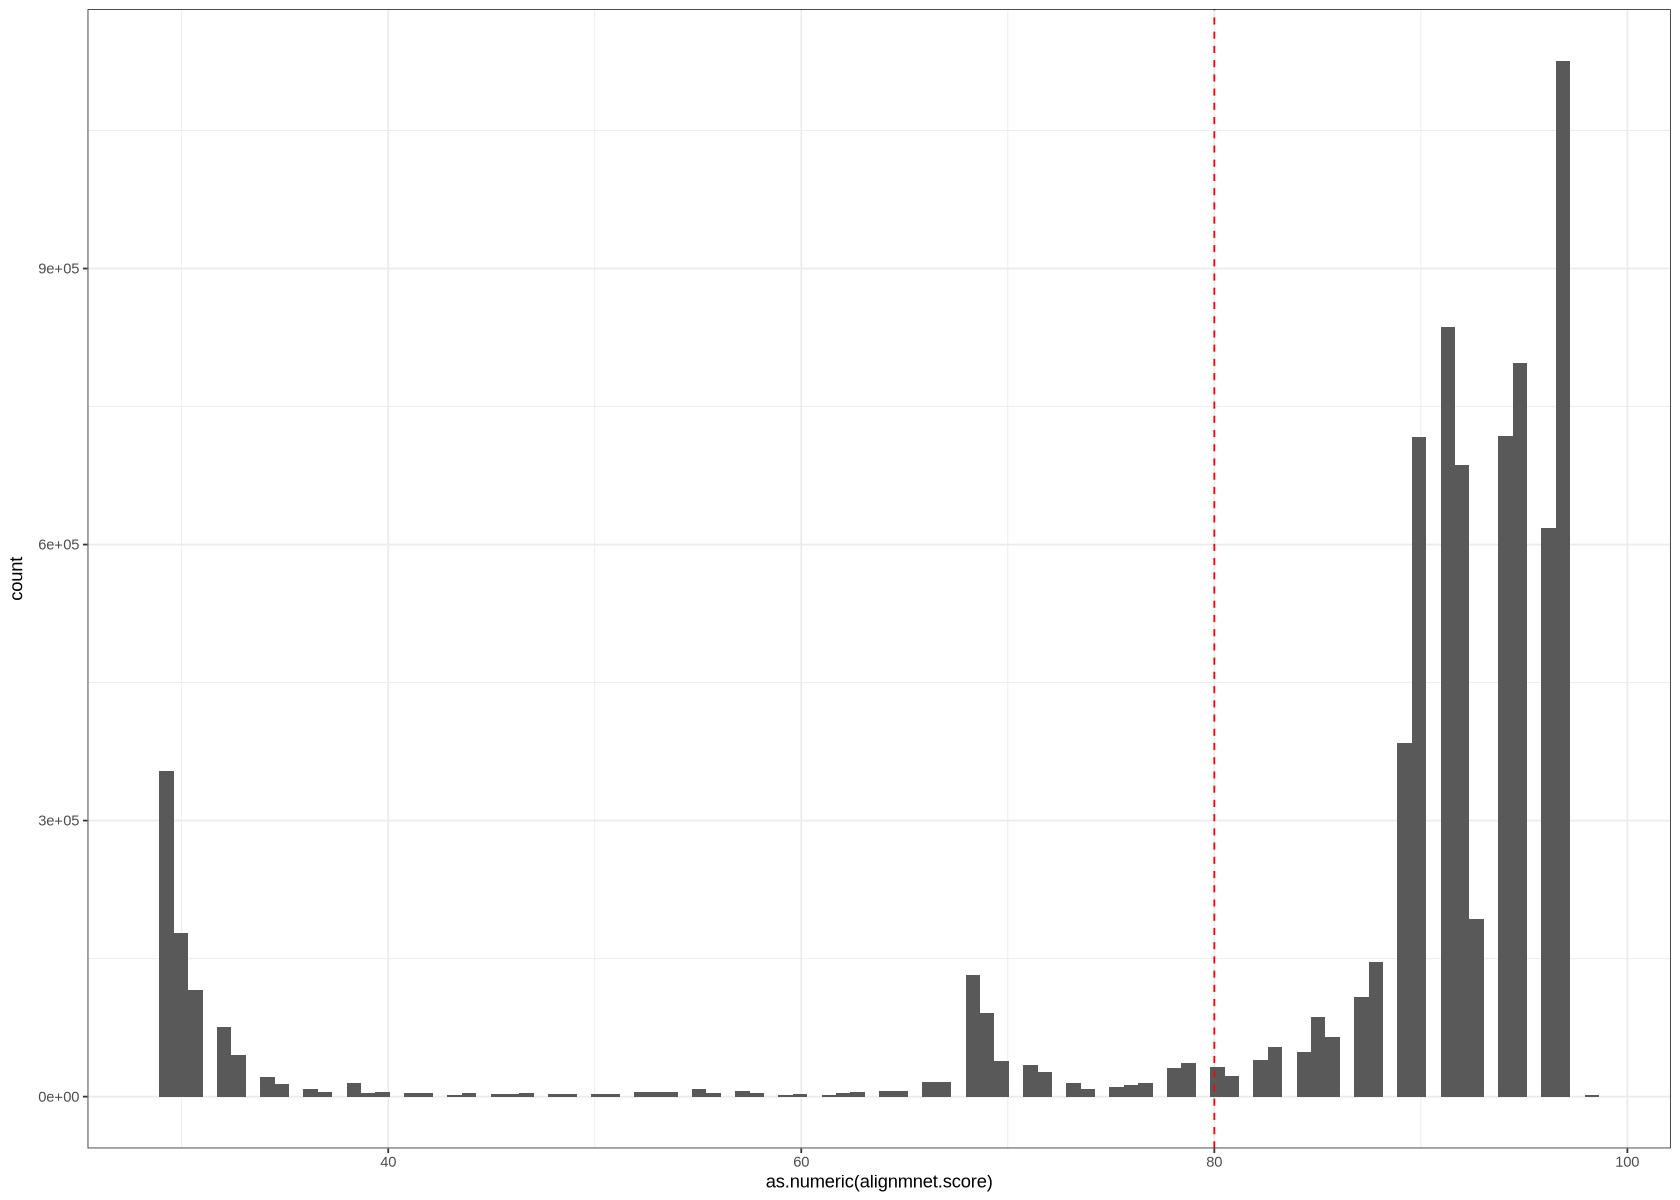

In [39]:
alignment.score.cutoff <- 80
ggplot(df, aes(x=as.numeric(alignment.score)))+
geom_histogram(bins = 100)+
geom_vline(xintercept = alignment.score.cutoff, linetype = "dashed", color = "red")+
theme_bw()

In [40]:
df <- df[n.alignments <= n.alignment.cutoff]
df <- df[alignment.score > alignment.score.cutoff]
df <- df %>% dplyr::select(-n.alignments, -alignmnet.score, -MAPQ)

In [60]:
#collapse PCR duplicate reads. 
df_collapsed <- df[, .N, by = .(Strand, Alignment, Alignment_Position, Cellbc, UMI)]
setnames(df_collapsed, "N", "PCR_Dups")

In [61]:
#filter barcodes passing my atac QC parameters
df_collapsed[, Cellbc := gsub("_", "", sub("^CR:Z:", "", Cellbc))]

meta.filt <- meta %>% filter(sublibrary == "SS-PKR-624") %>% 
mutate(Cellbc = stri_split_fixed(barcode, pattern = "_", simplify = TRUE)[,1])
df_collapsed <- df_collapsed %>% filter(Cellbc %in% meta.filt$Cellbc)

In [62]:
##if a umi occurs in the same cell x tf, it is prob the same read (so just a PCR DUP). so collapse position. 
df_collapsed <- df_collapsed %>%
group_by(Alignment, Cellbc, UMI)%>%
summarize(PCR_Dups = sum(PCR_Dups))

`summarise()` has grouped output by 'Alignment', 'Cellbc'. You can override
using the `.groups` argument.


In [63]:
#get rid of polyG UMIs
df_collapsed <- df_collapsed %>% filter(UMI != "GGGGGGGGGG")

Before we do more stringent filtering, lets make a cells x tf matrix. 

In [64]:
head(df_collapsed)

Alignment,Cellbc,UMI,PCR_Dups
<chr>,<chr>,<chr>,<int>
ASCL2_TFORF3108_NM_005170.2,ACAGTGGTACAGTGGTGCATGGCT,GGATGGTGGG,1
ASCL2_TFORF3108_NM_005170.2,ACAGTGGTGCAATCCGTACAGGAT,GGTGTAAACG,1
ASCL2_TFORF3108_NM_005170.2,ACAGTGGTGCCTGTTCTTCCATTG,CCAGTAGTCA,1
ASCL2_TFORF3108_NM_005170.2,ACAGTGGTGGATTAGGTCGTTAGC,TGAGTGGGAT,1
ASCL2_TFORF3108_NM_005170.2,ACAGTGGTGTGTCCTTTCAGATTC,CGGGGTCTGG,1
ASCL2_TFORF3108_NM_005170.2,ACAGTGGTGTGTGTCGTTAGGCAT,GTTGCGGTTT,1


In [65]:
input.mx <- df_collapsed %>% dplyr::select(-PCR_Dups, -UMI) %>% 
group_by(Alignment, Cellbc)%>%
summarize(n.umi = n())%>%
#  count(across(everything())) %>%
pivot_wider(names_from = Alignment, values_from = n.umi, values_fill = 0)%>%
column_to_rownames("Cellbc") %>% as.matrix()

col.df <- data.frame(tf = colnames(input.mx))
rownames(col.df) <- NULL
col.df$TF <- stri_split_fixed(col.df$tf, pattern = "_", simplify = TRUE)[,1]

col.df <- col.df %>% group_by(TF) %>% arrange(tf)%>% 
mutate(isoform = row_number())%>% mutate(TF = ifelse(isoform ==1, TF, paste0(TF, "_2"))) %>% ungroup()%>%
arrange(TF)

input.mx <- input.mx[,col.df$tf]
colnames(input.mx) <- col.df$TF


row.df <- data.frame(cellbc = rownames(input.mx),
                     n.tf = rowSums(input.mx > 0),
                    top.tf = colnames(input.mx)[max.col(input.mx, ties.method = "first")],
                     top.tf.val = apply(input.mx, 1, max)
)
rownames(row.df) <- NULL
row.df <- row.df %>% filter(n.tf >0)

row.df <- row.df %>%
  #arrange(n.tf, match(top.tf, col.df$TF), -top.tf.val)
  arrange(match(top.tf, col.df$TF), -top.tf.val)

input.mx <- input.mx[row.df$cellbc,]

cutoff <- 0.99

col_fun<-colorRamp2(c(0, 0.99, 1, quantile(input.mx, cutoff)), c("grey95", "grey90", "rosybrown1", "darkred"))

`summarise()` has grouped output by 'Alignment'. You can override using the
`.groups` argument.


`use_raster` is automatically set to TRUE for a matrix with more than
2000 rows. You can control `use_raster` argument by explicitly setting
TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.



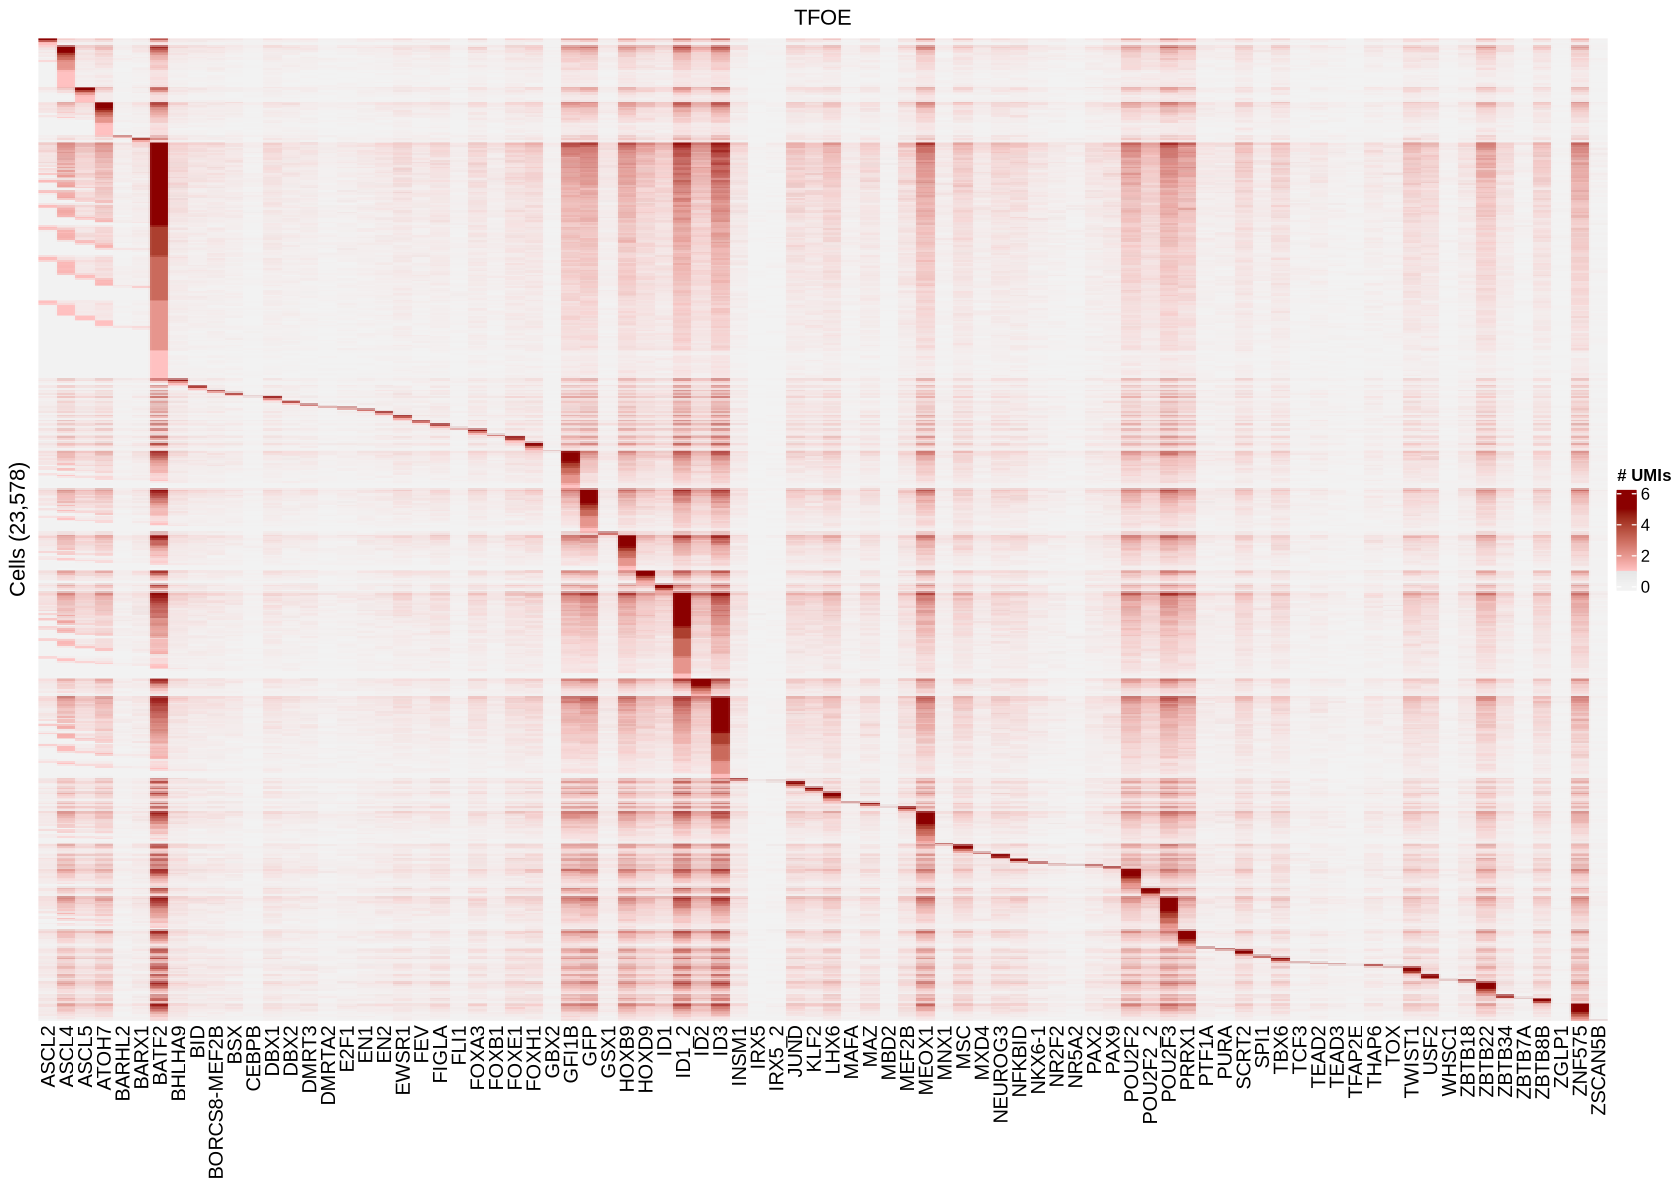

In [66]:
options(repr.plot.width = 14, repr.plot.height = 10)
Heatmap(input.mx,
       col = col_fun,
        cluster_rows = FALSE,
        cluster_columns = FALSE,
       show_row_names = FALSE,
       show_column_names = TRUE,
       show_row_dend = FALSE,
       show_column_dend = FALSE,
      heatmap_legend_param = list(title = "# UMIs"),
        row_title = paste0("Cells (", scales::label_comma()(nrow(input.mx)), ")"),
        column_title = "TFOE"
)

In [67]:
test.cell <- "TGAACTGGGTCTTGGCTATGCCAG"

df_collapsed %>% filter(Cellbc == test.cell) %>% group_by(UMI)%>% mutate(n = n())%>% arrange(-n)

Alignment,Cellbc,UMI,PCR_Dups,n
<chr>,<chr>,<chr>,<int>,<int>
ID2_TFORF2991_NM_002166.4,TGAACTGGGTCTTGGCTATGCCAG,CAACGTGAAA,1,6
MAZ_TFORF0052_NM_001276275,TGAACTGGGTCTTGGCTATGCCAG,CAACGTGAAA,2,6
POU2F2_TFORF1864_NM_001207025,TGAACTGGGTCTTGGCTATGCCAG,CAACGTGAAA,1,6
POU2F3_TFORF2206_NM_014352,TGAACTGGGTCTTGGCTATGCCAG,CAACGTGAAA,2,6
PRRX1_TFORF1218_NM_006902,TGAACTGGGTCTTGGCTATGCCAG,CAACGTGAAA,1,6
USF2_TFORF1800_NM_001321150,TGAACTGGGTCTTGGCTATGCCAG,CAACGTGAAA,60,6
ID1_TFORF2860_NM_002165,TGAACTGGGTCTTGGCTATGCCAG,GCGGTGAAGG,1,3
POU2F3_TFORF2206_NM_014352,TGAACTGGGTCTTGGCTATGCCAG,GCGGTGAAGG,2,3
USF2_TFORF1800_NM_001321150,TGAACTGGGTCTTGGCTATGCCAG,GCGGTGAAGG,33,3


Warning message in scale_y_continuous(trans = "log10"):
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 101 rows containing missing values or values outside the scale range
(`geom_bar()`).”


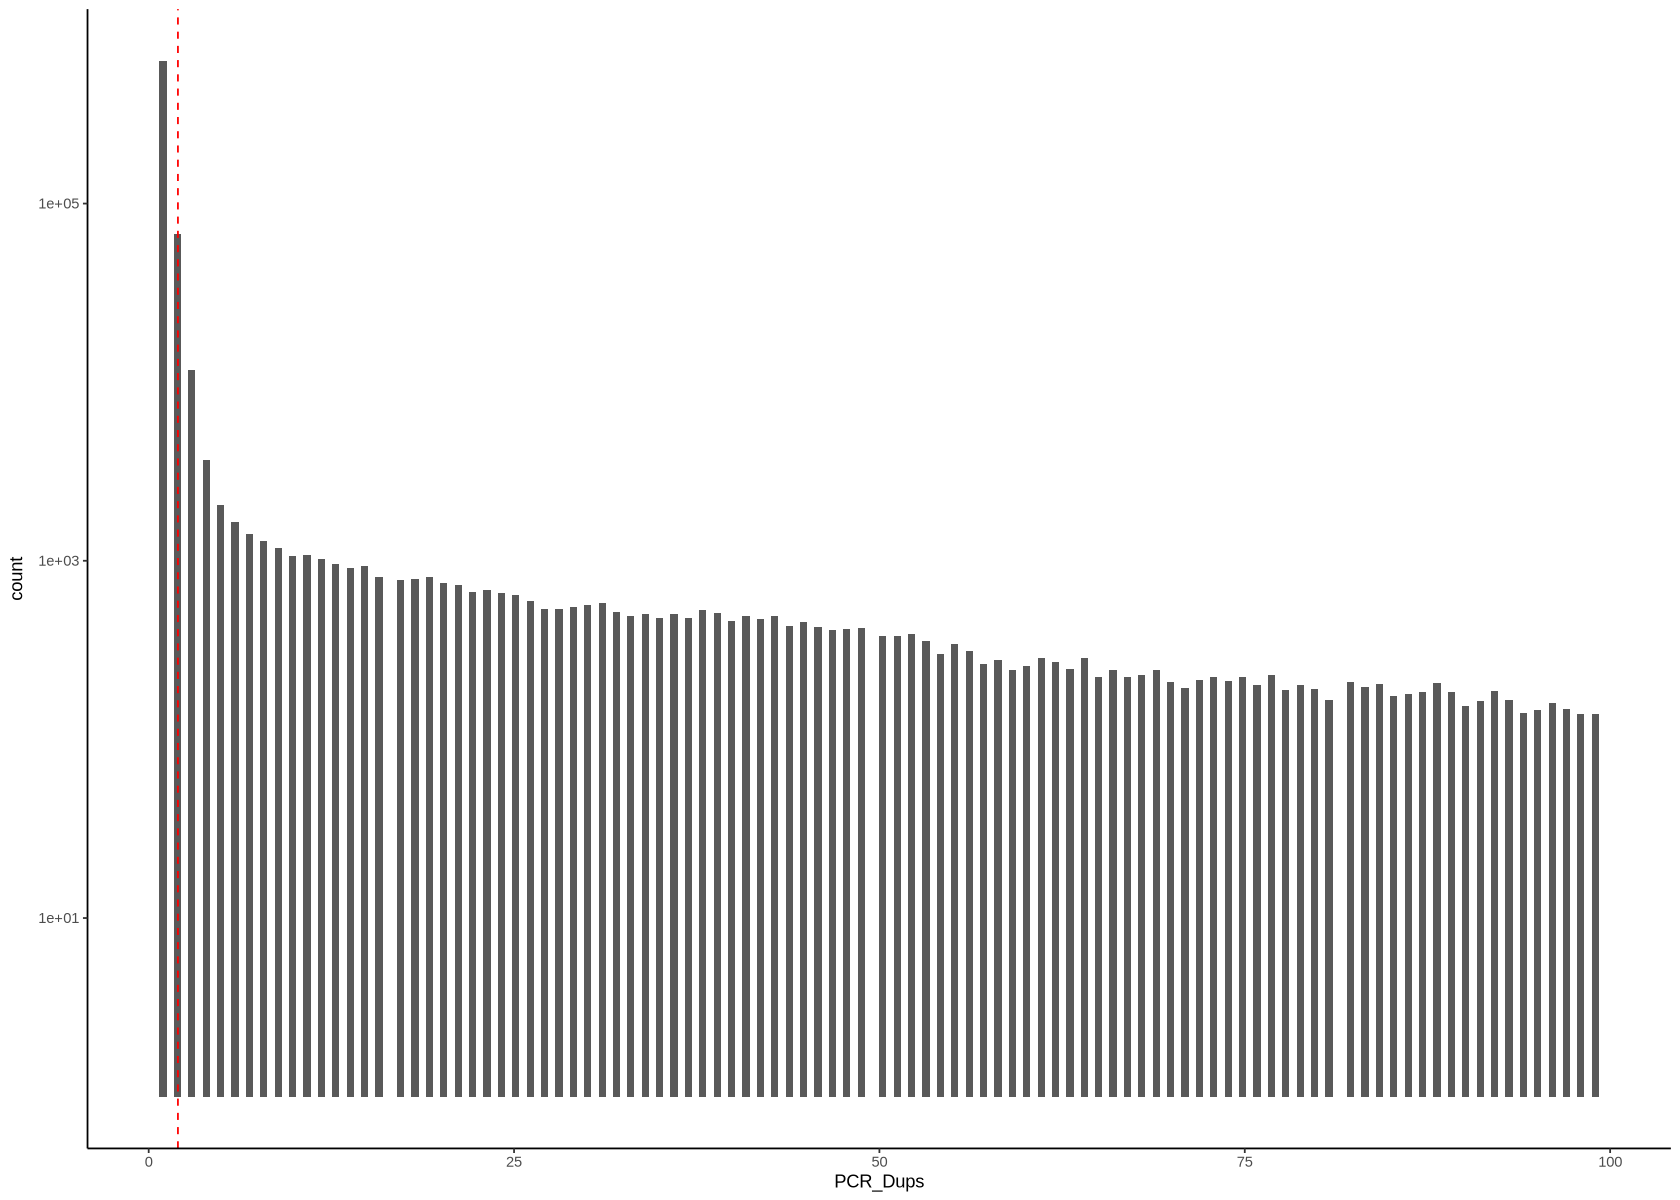

In [68]:
read.support.umi.cutoff<- 2


df_collapsed %>% 
filter(PCR_Dups>0& PCR_Dups<100)%>%
ggplot(aes(x=PCR_Dups))+
geom_histogram(bins = 200)+
theme_classic()+
scale_y_continuous(trans = "log10")+
geom_vline(xintercept = read.support.umi.cutoff, linetype="dashed", color ="red")

In [69]:
input.mx <- df_collapsed %>%
filter(PCR_Dups>read.support.umi.cutoff)%>%
dplyr::select(-PCR_Dups, -UMI) %>% 
count(across(everything())) %>%
pivot_wider(names_from = Alignment, values_from = n, values_fill = 0)%>%
column_to_rownames("Cellbc") %>% as.matrix()

col.df <- data.frame(tf = colnames(input.mx))
rownames(col.df) <- NULL
col.df$TF <- stri_split_fixed(col.df$tf, pattern = "_", simplify = TRUE)[,1]

col.df <- col.df %>% group_by(TF) %>% arrange(tf)%>% 
mutate(isoform = row_number())%>% mutate(TF = ifelse(isoform ==1, TF, paste0(TF, "_2"))) %>% ungroup()%>%
arrange(TF)

input.mx <- input.mx[,col.df$tf]
colnames(input.mx) <- col.df$TF


row.df <- data.frame(cellbc = rownames(input.mx),
                     n.tf = rowSums(input.mx > 0),
                    top.tf = colnames(input.mx)[max.col(input.mx, ties.method = "first")],
                     top.tf.val = apply(input.mx, 1, max)
)
rownames(row.df) <- NULL
row.df <- row.df %>% filter(n.tf >0)

row.df <- row.df %>%
  #arrange(n.tf, match(top.tf, col.df$TF), -top.tf.val)
  arrange(match(top.tf, col.df$TF), -top.tf.val)

input.mx <- input.mx[row.df$cellbc,]



`use_raster` is automatically set to TRUE for a matrix with more than
2000 rows. You can control `use_raster` argument by explicitly setting
TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.



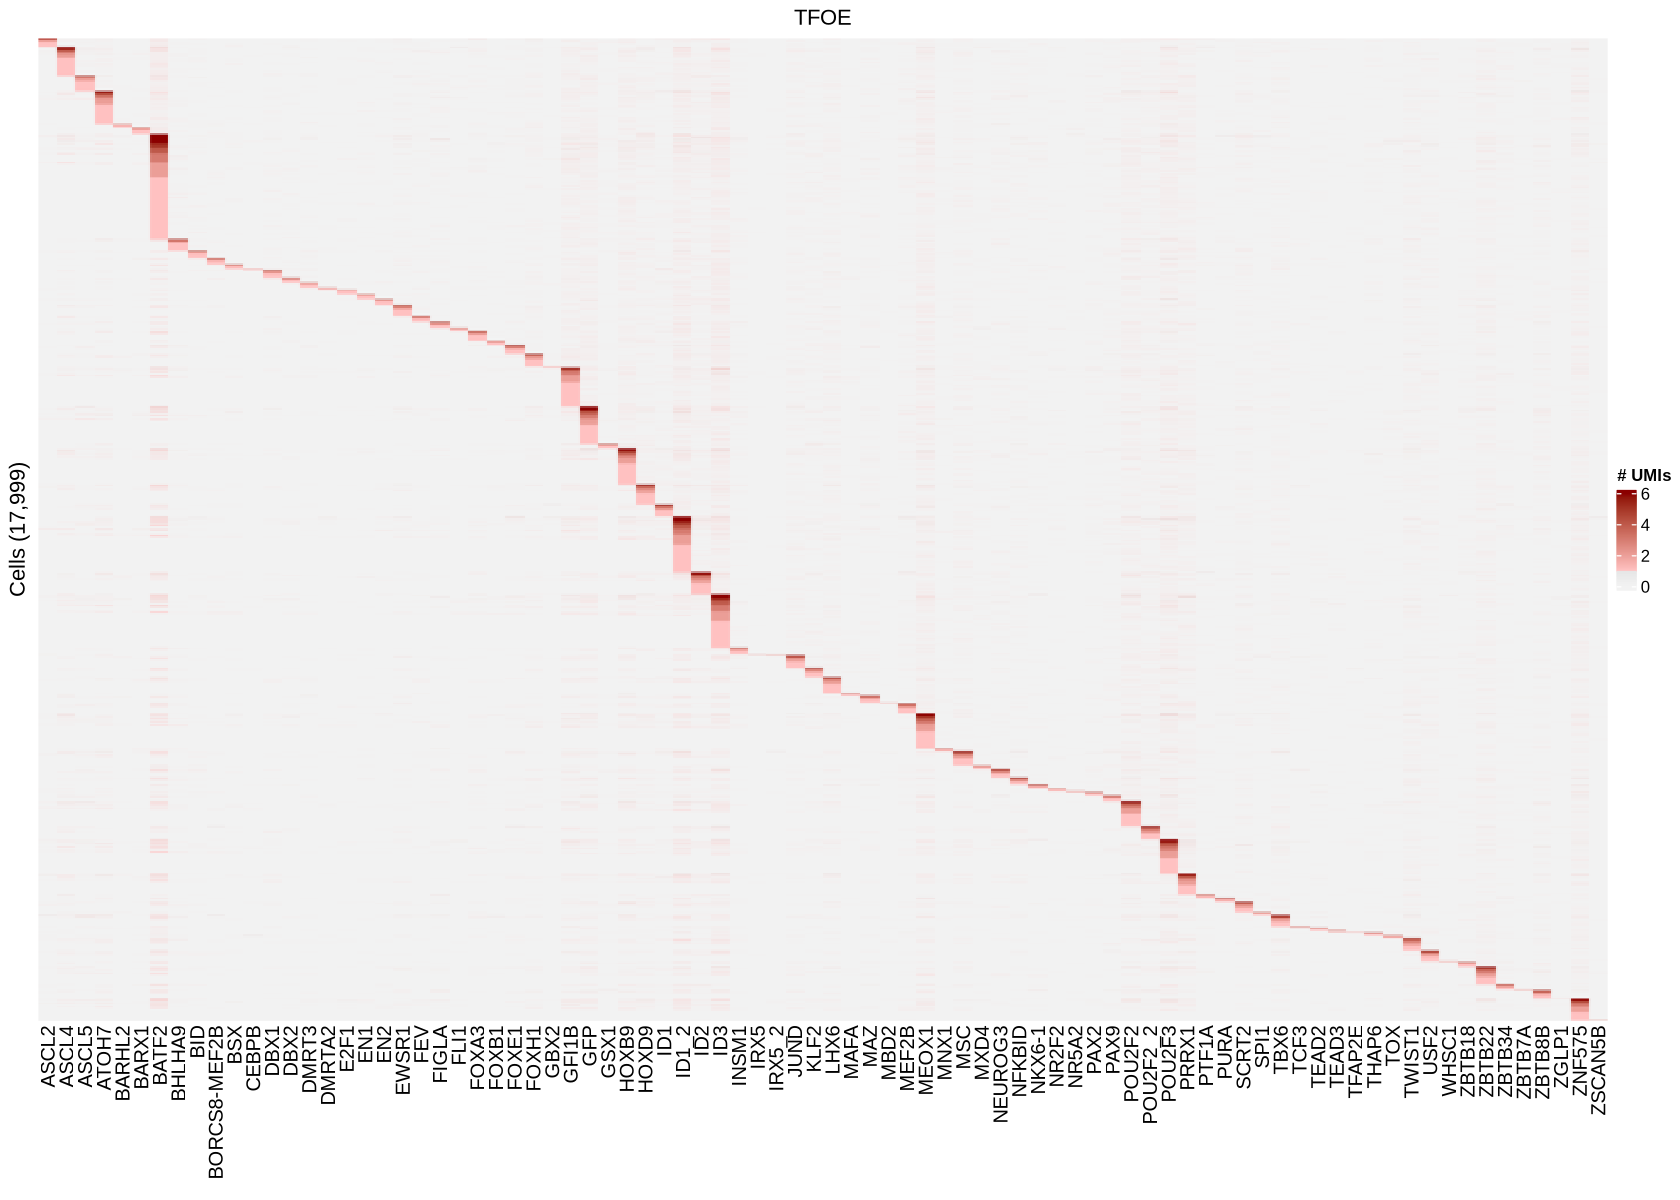

In [70]:
cutoff <- 0.99

col_fun<-colorRamp2(c(0, 0.99, 1, quantile(input.mx, cutoff)), c("grey95", "grey90", "rosybrown1", "darkred"))
col_fun<-colorRamp2(c(0, 0.99, 1, 6), c("grey95", "grey90", "rosybrown1", "darkred"))

options(repr.plot.width = 14, repr.plot.height = 10)
Heatmap(input.mx,
       col = col_fun,
        cluster_rows = FALSE,
        cluster_columns = FALSE,
       show_row_names = FALSE,
       show_column_names = TRUE,
       show_row_dend = FALSE,
       show_column_dend = FALSE,
      heatmap_legend_param = list(title = "# UMIs"),
        row_title = paste0("Cells (", scales::label_comma()(nrow(input.mx)), ")"),
        column_title = "TFOE"
)

Hypergeometric distribution

In [73]:
filt <- df_collapsed %>% 
filter(PCR_Dups>read.support.umi.cutoff)%>%
group_by(Alignment, Cellbc)%>%
summarize(n.UMIs = length(unique(UMI)),
            n.pcr.reads = sum(PCR_Dups))

`summarise()` has grouped output by 'Alignment'. You can override using the
`.groups` argument.


In [105]:
head(filt)

Alignment,Cellbc,n.UMIs,n.pcr.reads
<chr>,<chr>,<int>,<int>
ASCL2_TFORF3108_NM_005170.2,ACAGTGGTTTCAGCTCGAATCTGT,1,14
ASCL2_TFORF3108_NM_005170.2,ACTTGATGGCCAATGTTCAGATTC,1,3
ASCL2_TFORF3108_NM_005170.2,ACTTGATGGTGTGTCGGCCTGTTC,1,9
ASCL2_TFORF3108_NM_005170.2,ACTTGATGTCAGGAGGGCATGGCT,1,3
ASCL2_TFORF3108_NM_005170.2,ACTTGATGTGCTGATAGTACATCT,2,73
ASCL2_TFORF3108_NM_005170.2,ACTTGATGTTCTGTGTGTAAGGTG,1,4


In [173]:
background.distribution <- filt %>% 
group_by(Alignment) %>% 
summarize(n.UMIs.total = sum(n.UMIs),
          n.PCR.total = sum(n.pcr.reads))
total.umis <- sum(background.distribution$n.UMIs.total)
total.pcrs <- sum(background.distribution$n.PCR.total)

background.distribution$non.tf.umis <- total.umis-background.distribution$n.UMIs.total
background.distribution$non.tf.pcr <- total.pcrs-background.distribution$n.PCR.total

cell.tf.distribution <- filt %>% 
group_by(Cellbc)%>%
mutate(n.umi.cell = sum(n.UMIs),
       n.pcr.cell = sum(n.pcr.reads)) %>%
left_join(background.distribution) %>%
mutate(hyperp.umis = phyper(q = n.UMIs - 1, 
                       m = n.UMIs, 
                       n = non.tf.umis, 
                       k = n.umi.cell, 
                       lower.tail = FALSE, log.p = FALSE)) %>%
mutate(hyperp.pcr = phyper(q = n.pcr.reads - 1, 
                       m = n.PCR.total, 
                       n = non.tf.pcr, 
                       k = n.pcr.cell, 
                        lower.tail = FALSE, log.p = FALSE))%>%
ungroup()

cell.tf.distribution$hyperp.umi.adj.all <- p.adjust(cell.tf.distribution$hyperp.umis, method = "BH")
cell.tf.distribution$hyperp.pcr.adj.all <- p.adjust(cell.tf.distribution$hyperp.pcr, method = "BH")

Joining with `by = join_by(Alignment)`


In [188]:
input.mx <- cell.tf.distribution %>% 
mutate(logp = -log10((hyperp.umi.adj.all)))%>%
dplyr::select(Cellbc, Alignment, logp) %>%
pivot_wider(names_from = Alignment, values_from = logp, values_fill = 0) %>%
column_to_rownames("Cellbc")%>% as.matrix()

col.df <- data.frame(tf = colnames(input.mx))
rownames(col.df) <- NULL
col.df$TF <- stri_split_fixed(col.df$tf, pattern = "_", simplify = TRUE)[,1]

col.df <- col.df %>% group_by(TF) %>% arrange(tf)%>% 
mutate(isoform = row_number())%>% mutate(TF = ifelse(isoform ==1, TF, paste0(TF, "_2"))) %>% ungroup()%>%
arrange(TF)

input.mx <- input.mx[,col.df$tf]
colnames(input.mx) <- col.df$TF


row.df <- data.frame(cellbc = rownames(input.mx),
                     n.tf = rowSums(input.mx > 1.3),
                    top.tf = colnames(input.mx)[max.col(input.mx, ties.method = "first")],
                     top.tf.val = apply(input.mx, 1, max)
)
rownames(row.df) <- NULL
row.df <- row.df %>% filter(n.tf >0)

row.df <- row.df %>%
  #arrange(n.tf, match(top.tf, col.df$TF), -top.tf.val)
  arrange(match(top.tf, col.df$TF), -top.tf.val)

input.mx <- input.mx[row.df$cellbc,]



`use_raster` is automatically set to TRUE for a matrix with more than
2000 rows. You can control `use_raster` argument by explicitly setting
TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.



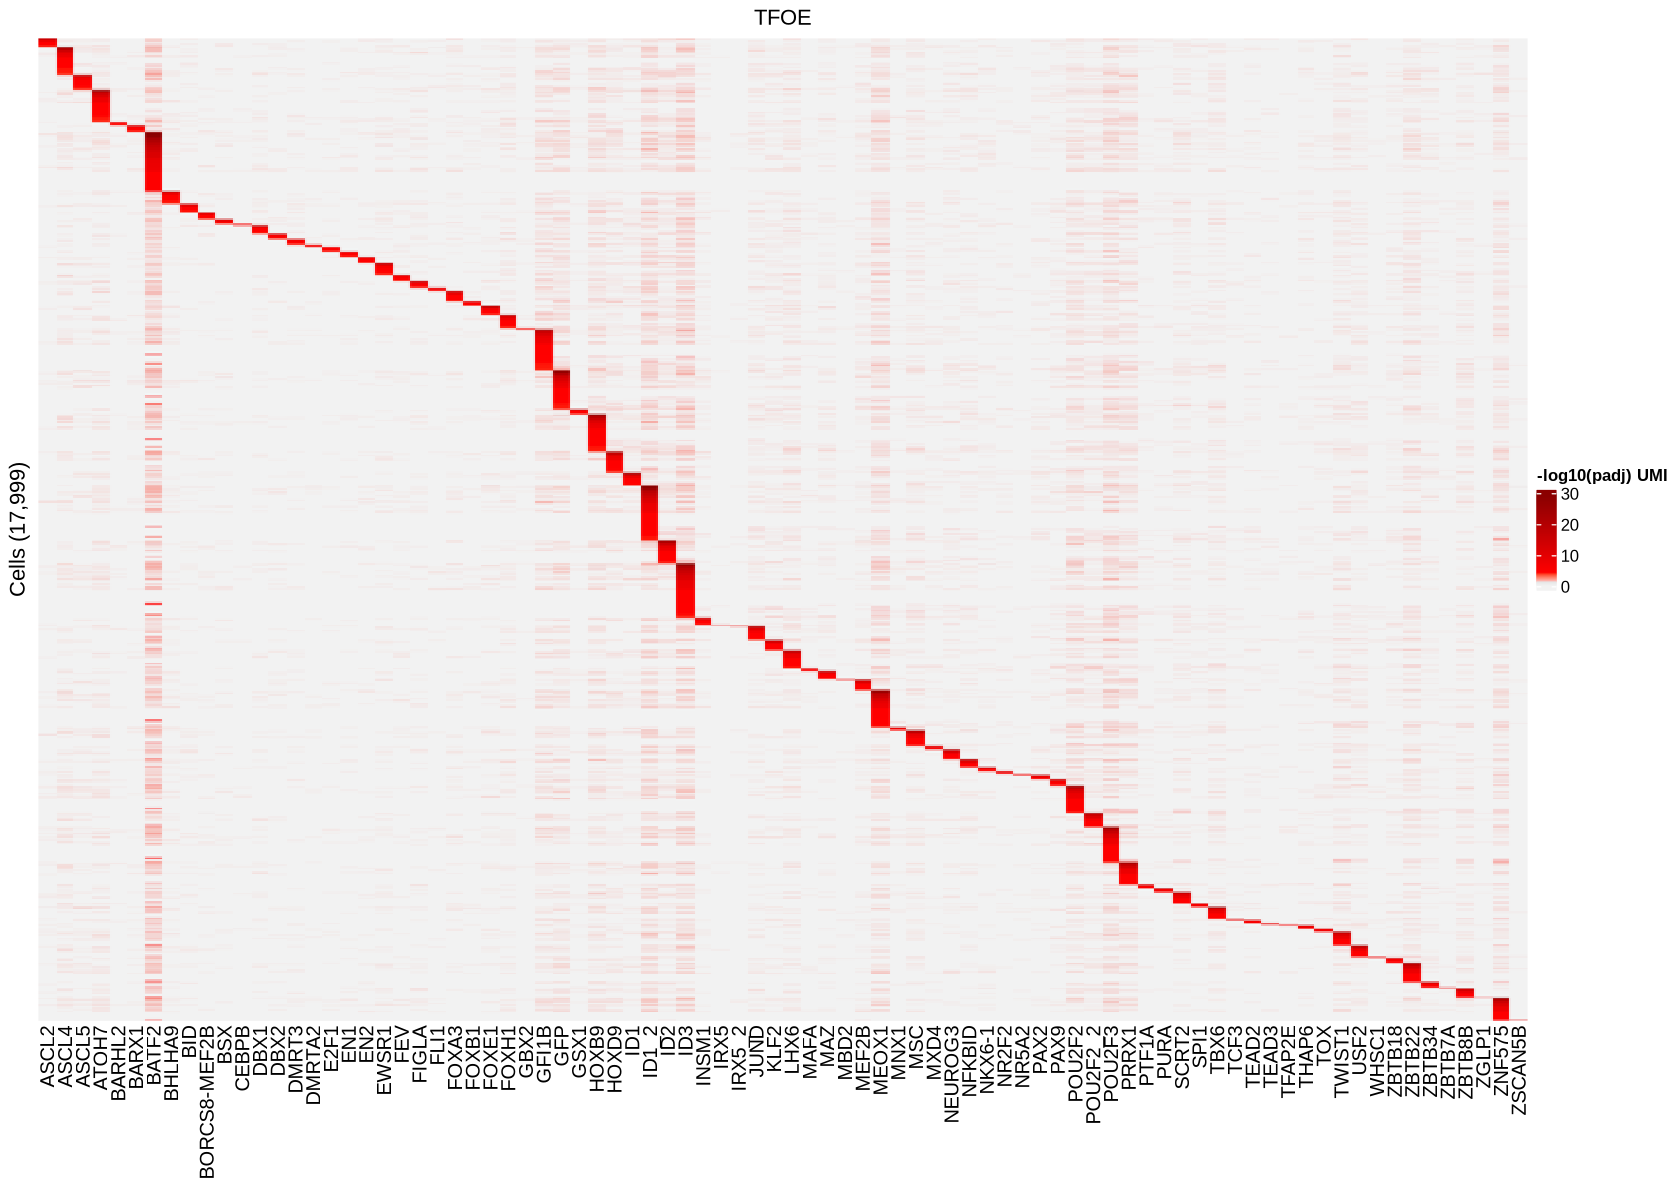

In [189]:
cutoff<-0.99
col_fun<-colorRamp2(c(0, 1.29, 1.3, quantile(input.mx[input.mx>1.3], cutoff/2), quantile(input.mx[input.mx>1.3], cutoff)), c("grey95", "grey90", "rosybrown1", "red", "darkred"))

options(repr.plot.width = 14, repr.plot.height = 10)
Heatmap(input.mx,
       col = col_fun,
        cluster_rows = FALSE,
        cluster_columns = FALSE,
       show_row_names = FALSE,
       show_column_names = TRUE,
       show_row_dend = FALSE,
       show_column_dend = FALSE,
      heatmap_legend_param = list(title = "-log10(padj) UMI"),
        row_title = paste0("Cells (", scales::label_comma()(nrow(input.mx)), ")"),
        column_title = "TFOE"
)

In [190]:
input.mx <- cell.tf.distribution %>% 
mutate(logp = -log10((hyperp.pcr.adj.all)))%>%
dplyr::select(Cellbc, Alignment, logp) %>%
pivot_wider(names_from = Alignment, values_from = logp, values_fill = 0) %>%
column_to_rownames("Cellbc")%>% as.matrix()

col.df <- data.frame(tf = colnames(input.mx))
rownames(col.df) <- NULL
col.df$TF <- stri_split_fixed(col.df$tf, pattern = "_", simplify = TRUE)[,1]

col.df <- col.df %>% group_by(TF) %>% arrange(tf)%>% 
mutate(isoform = row_number())%>% mutate(TF = ifelse(isoform ==1, TF, paste0(TF, "_2"))) %>% ungroup()%>%
arrange(TF)

input.mx <- input.mx[,col.df$tf]
colnames(input.mx) <- col.df$TF


row.df <- data.frame(cellbc = rownames(input.mx),
                     n.tf = rowSums(input.mx > 1.3),
                    top.tf = colnames(input.mx)[max.col(input.mx, ties.method = "first")],
                     top.tf.val = apply(input.mx, 1, max)
)
rownames(row.df) <- NULL
row.df <- row.df %>% filter(n.tf >0)

row.df <- row.df %>%
  #arrange(n.tf, match(top.tf, col.df$TF), -top.tf.val)
  arrange(match(top.tf, col.df$TF), -top.tf.val)

input.mx <- input.mx[row.df$cellbc,]

`use_raster` is automatically set to TRUE for a matrix with more than
2000 rows. You can control `use_raster` argument by explicitly setting
TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.



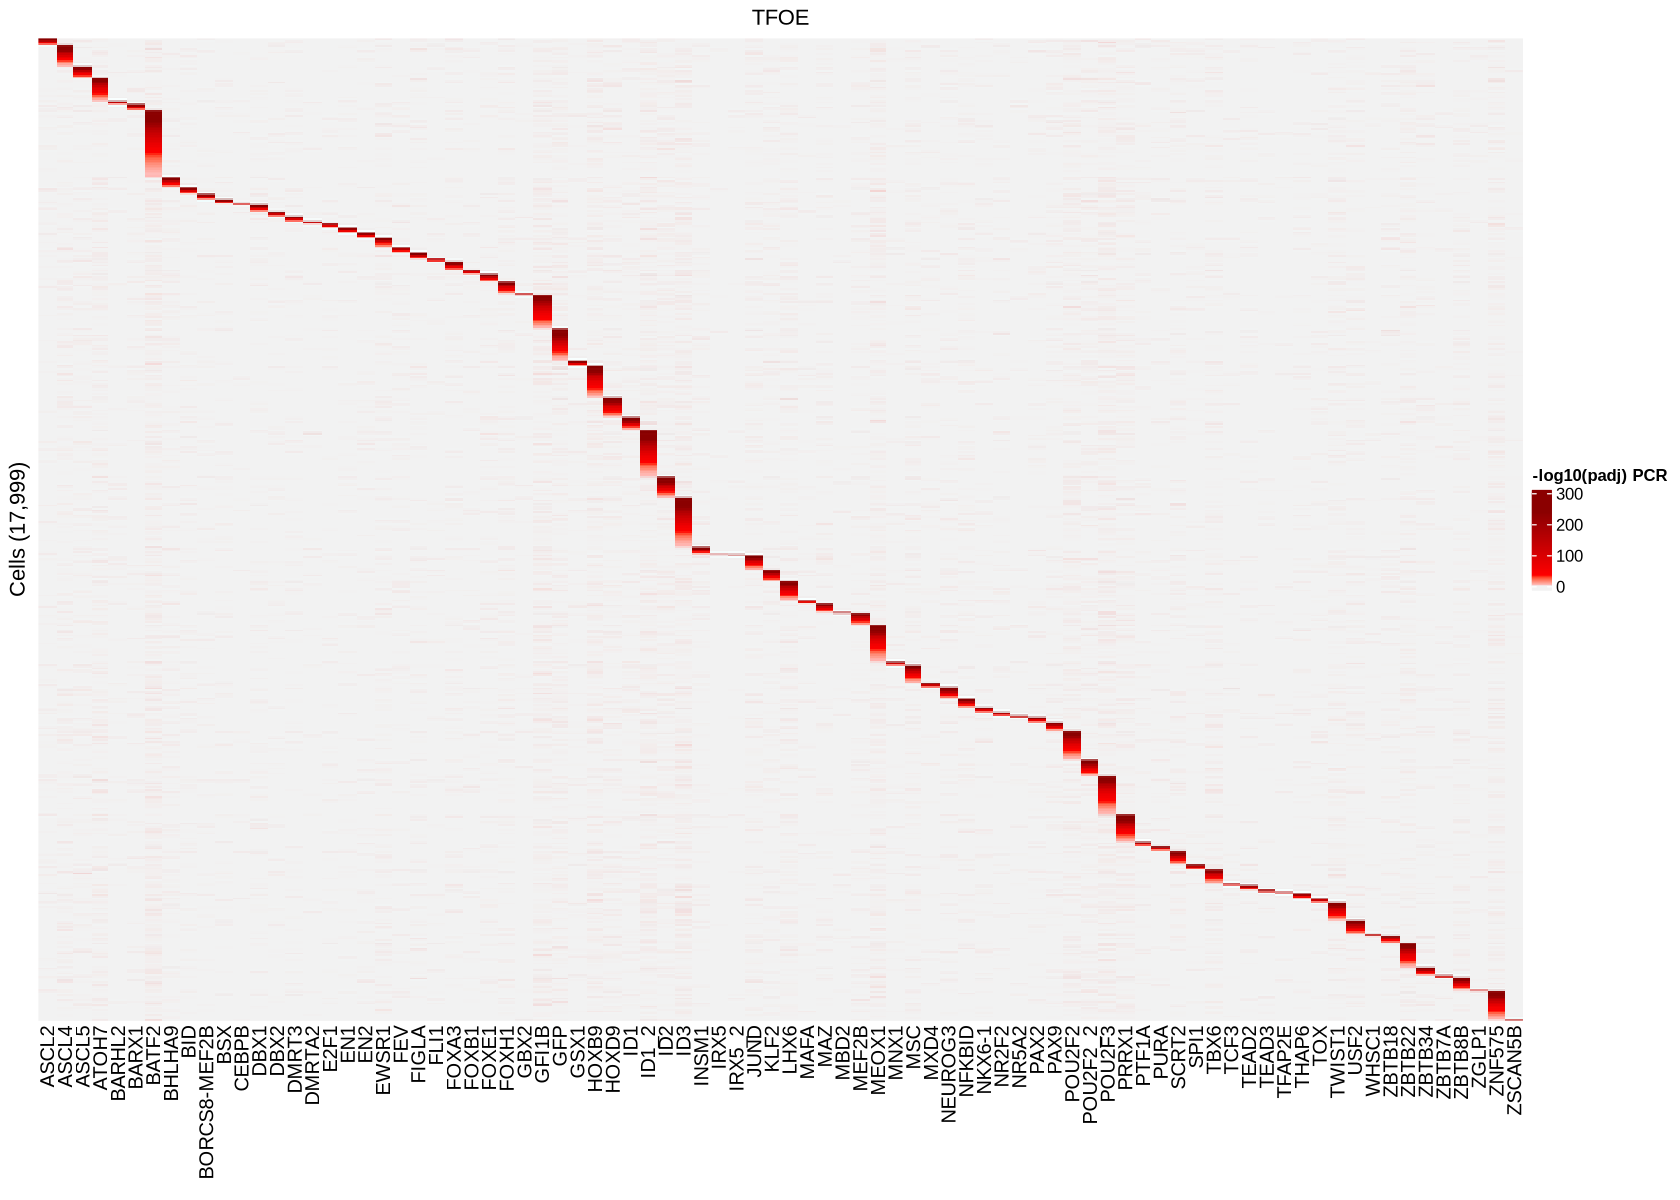

In [195]:
cutoff<-0.95
col_fun<-colorRamp2(c(0, 1.29, 1.3, quantile(input.mx[input.mx>1.3&!is.infinite(input.mx)], cutoff/2), quantile(input.mx[input.mx>1.3&!is.infinite(input.mx)], cutoff)), c("grey95", "grey90", "rosybrown1", "red", "darkred"))

options(repr.plot.width = 14, repr.plot.height = 10)

Heatmap(input.mx,
       col = col_fun,
        cluster_rows = FALSE,
        cluster_columns = FALSE,
       show_row_names = FALSE,
       show_column_names = TRUE,
       show_row_dend = FALSE,
       show_column_dend = FALSE,
      heatmap_legend_param = list(title = "-log10(padj) PCR"),
        row_title = paste0("Cells (", scales::label_comma()(nrow(input.mx)), ")"),
        column_title = "TFOE"
)

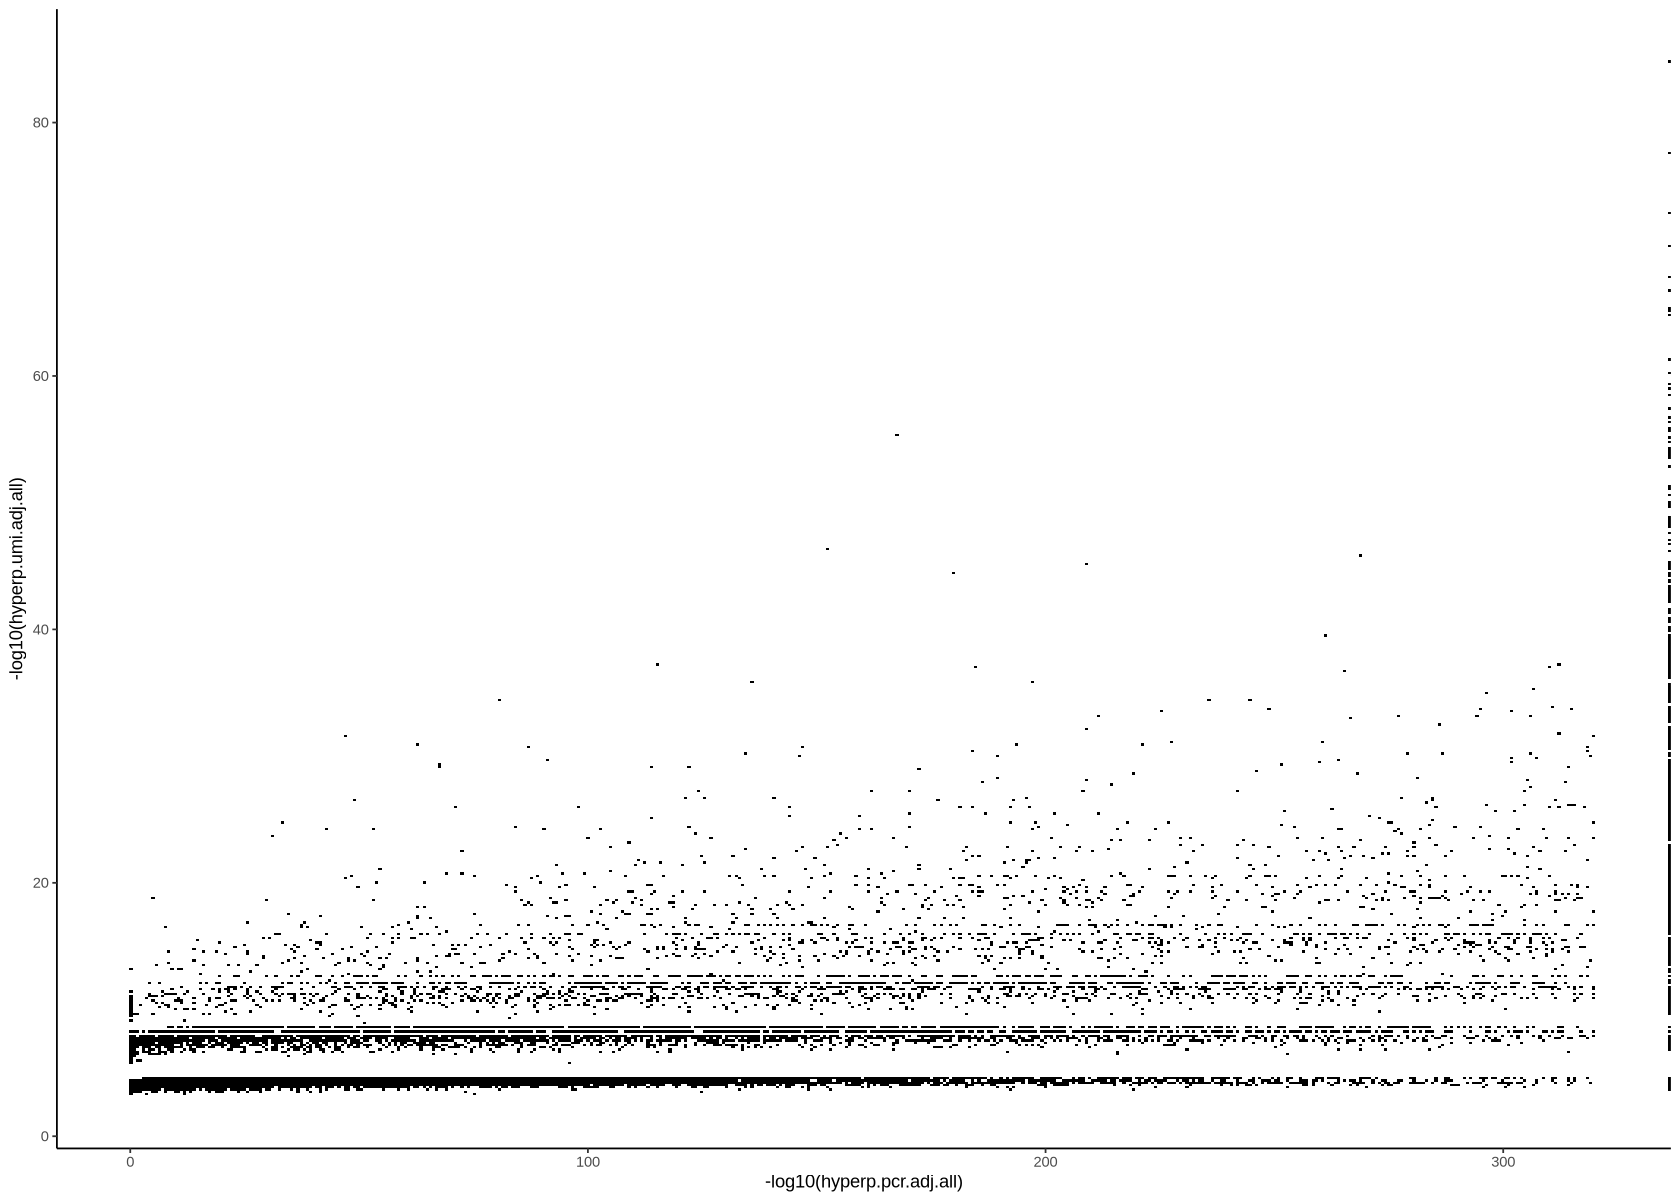

In [209]:
cell.tf.distribution %>% 
filter(hyperp.pcr.adj.all < 0.05 | hyperp.umi.adj.all < 0.05)%>%
ggplot(aes(x=-log10(hyperp.pcr.adj.all), y=-log10(hyperp.umi.adj.all)))+
geom_scattermore()+
theme_classic()

In [224]:
input.mx <- cell.tf.distribution %>%
filter(hyperp.pcr.adj.all < 0.005 & hyperp.umi.adj.all < 0.005)%>%
mutate(logp = -log10((hyperp.pcr.adj.all)))%>%
dplyr::select(Cellbc, Alignment, logp) %>%
pivot_wider(names_from = Alignment, values_from = logp, values_fill = 0) %>%
column_to_rownames("Cellbc")%>% as.matrix()

col.df <- data.frame(tf = colnames(input.mx))
rownames(col.df) <- NULL
col.df$TF <- stri_split_fixed(col.df$tf, pattern = "_", simplify = TRUE)[,1]

col.df <- col.df %>% group_by(TF) %>% arrange(tf)%>% 
mutate(isoform = row_number())%>% mutate(TF = ifelse(isoform ==1, TF, paste0(TF, "_2"))) %>% ungroup()%>%
arrange(TF)

input.mx <- input.mx[,col.df$tf]
colnames(input.mx) <- col.df$TF


row.df <- data.frame(cellbc = rownames(input.mx),
                     n.tf = rowSums(input.mx > 1.3),
                    top.tf = colnames(input.mx)[max.col(input.mx, ties.method = "first")],
                     top.tf.val = apply(input.mx, 1, max)
)
rownames(row.df) <- NULL
row.df <- row.df %>% filter(n.tf >0)

row.df <- row.df %>%
  #arrange(n.tf, match(top.tf, col.df$TF), -top.tf.val)
  arrange(match(top.tf, col.df$TF), -top.tf.val)

input.mx <- input.mx[row.df$cellbc,]

The automatically generated colors map from the 1^st and 99^th of the
values in the matrix. There are outliers in the matrix whose patterns
might be hidden by this color mapping. You can manually set the color
to `col` argument.

Use `suppressMessages()` to turn off this message.

`use_raster` is automatically set to TRUE for a matrix with more than
2000 rows. You can control `use_raster` argument by explicitly setting
TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.



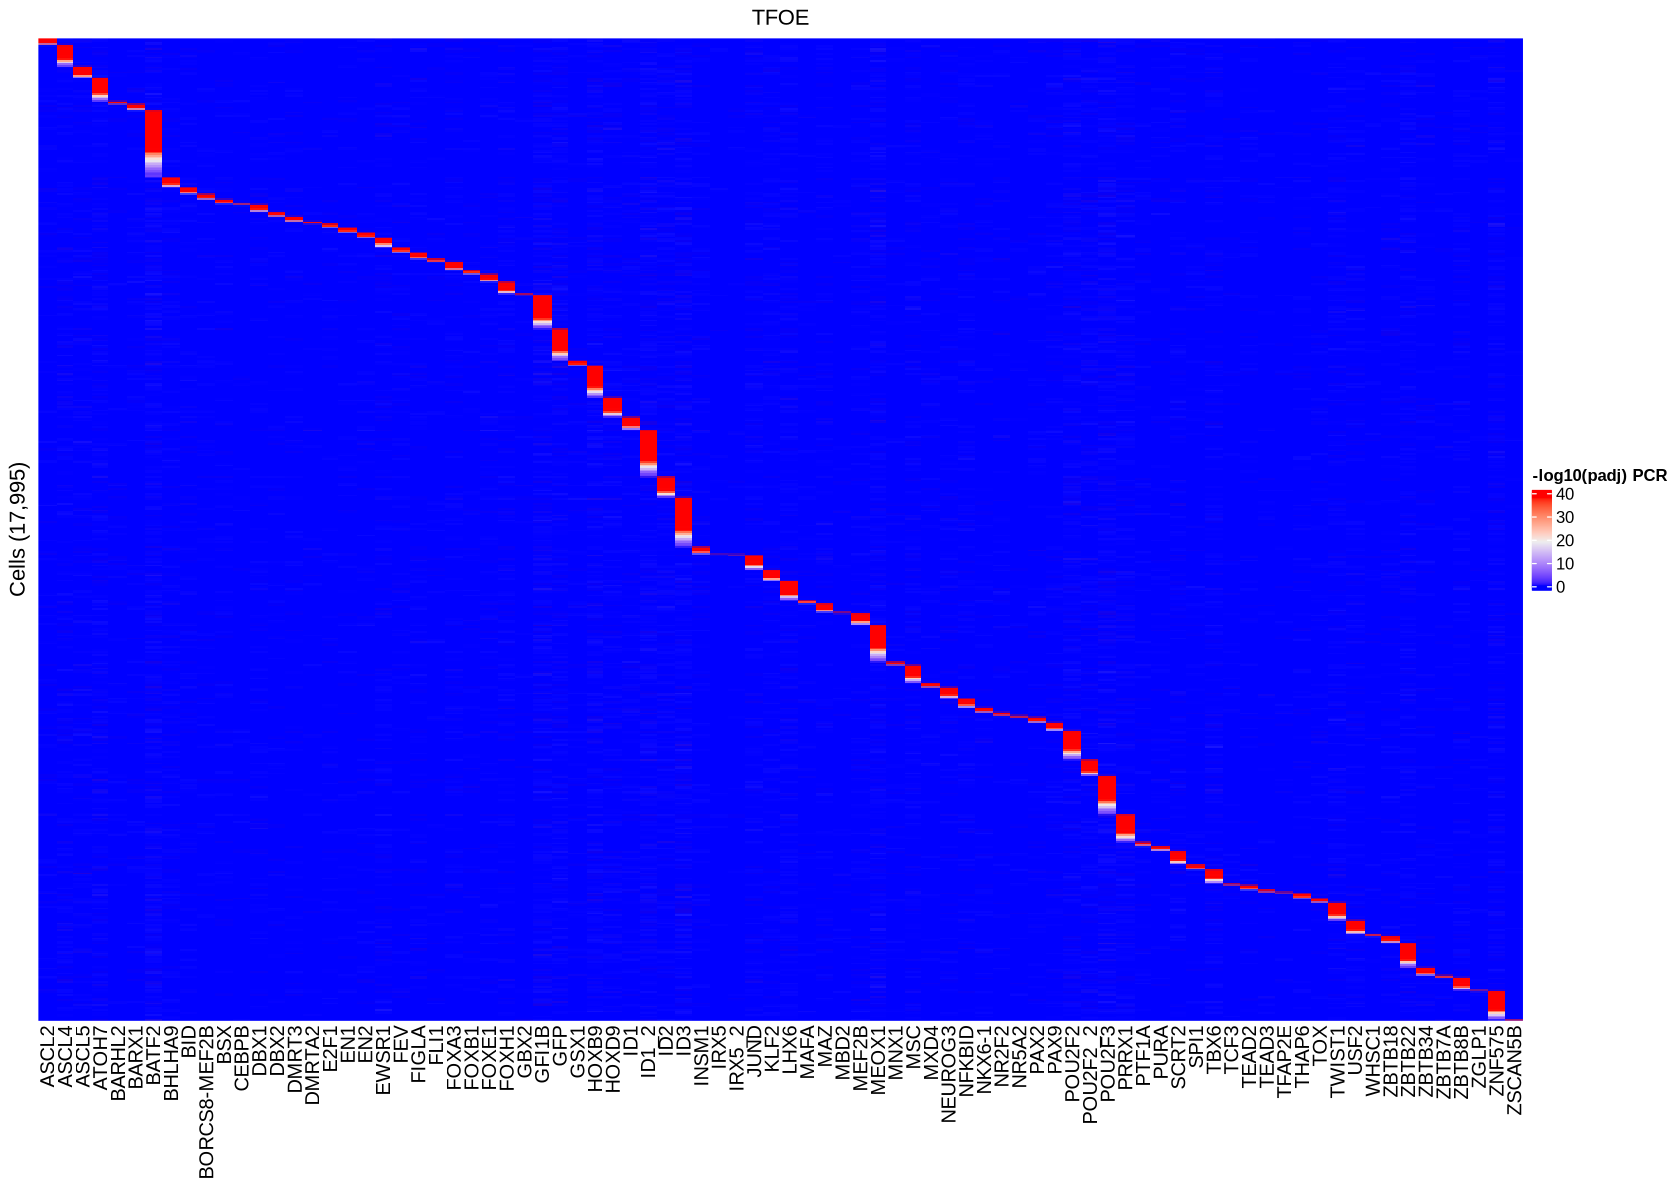

In [231]:
# cutoff<-0.99
# col_fun<-colorRamp2(c(0, 
#                       quantile(input.mx[input.mx>1.3&!is.infinite(input.mx)], 1-cutoff), 
#                       quantile(input.mx[input.mx>1.3&!is.infinite(input.mx)], 1-cutoff)+0.001, 
#                       quantile(input.mx[input.mx>1.3&!is.infinite(input.mx)], cutoff/2), 
#                       quantile(input.mx[input.mx>1.3&!is.infinite(input.mx)], cutoff)), 
#                     c("grey95", "grey90", "rosybrown1", "red", "darkred"))
# cutoff<-0.99
col_fun<-colorRamp2(c(0, 20,21, 30, 40), c("grey95", "grey90", "rosybrown1", "red", "darkred"))

options(repr.plot.width = 14, repr.plot.height = 10)
Heatmap(input.mx,
#       col = col_fun,
        cluster_rows = FALSE,
        cluster_columns = FALSE,
       show_row_names = FALSE,
       show_column_names = TRUE,
       show_row_dend = FALSE,
       show_column_dend = FALSE,
      heatmap_legend_param = list(title = "-log10(padj) PCR"),
        row_title = paste0("Cells (", scales::label_comma()(nrow(input.mx)), ")"),
        column_title = "TFOE"
)

Alignment,Cellbc,n.UMIs,n.pcr.reads,n.umi.cell,n.pcr.cell,n.UMIs.total,n.PCR.total,non.tf.umis,non.tf.pcr,hyperp.umis,hyperp.pcr,hyperp.umis.adj,hyperp.pcr.adj
<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
ASCL2_TFORF3108_NM_005170.2,ACAGTGGTTTCAGCTCGAATCTGT,1,14,1,14,378,14336,65056,2427253,1.537114e-05,5.752209e-32,1.537114e-05,5.752209e-32
ASCL2_TFORF3108_NM_005170.2,ACTTGATGGCCAATGTTCAGATTC,1,3,10,503,378,14336,65056,2427253,1.537114e-04,5.669517e-01,1.685374e-04,8.504276e-01
ASCL2_TFORF3108_NM_005170.2,ACTTGATGGTGTGTCGGCCTGTTC,1,9,2,60,378,14336,65056,2427253,3.074227e-05,9.340241e-11,3.148615e-05,9.340241e-11
ASCL2_TFORF3108_NM_005170.2,ACTTGATGTCAGGAGGGCATGGCT,1,3,5,102,378,14336,65056,2427253,7.685568e-05,2.259754e-02,8.000896e-05,3.013005e-02
ASCL2_TFORF3108_NM_005170.2,ACTTGATGTGCTGATAGTACATCT,2,73,6,198,378,14336,65056,2427253,7.088046e-09,1.253243e-108,1.063207e-08,3.759730e-108
ASCL2_TFORF3108_NM_005170.2,ACTTGATGTTCTGTGTGTAAGGTG,1,4,3,23,378,14336,65056,2427253,4.611341e-05,9.621843e-06,4.641089e-05,1.443276e-05


[1] 17889     2

Cellbc,n.tf
<chr>,<int>
ACAGTGGTACAGTGGTGCATGGCT,1
ACAGTGGTACAGTGGTTAACGCTG,2
ACAGTGGTACTTGATGGACGGATT,2
ACAGTGGTATCACGTTTGTACCTT,1
ACAGTGGTATCACGTTTTCCATTG,2
ACAGTGGTCAGATCTGTGTGAAGA,1


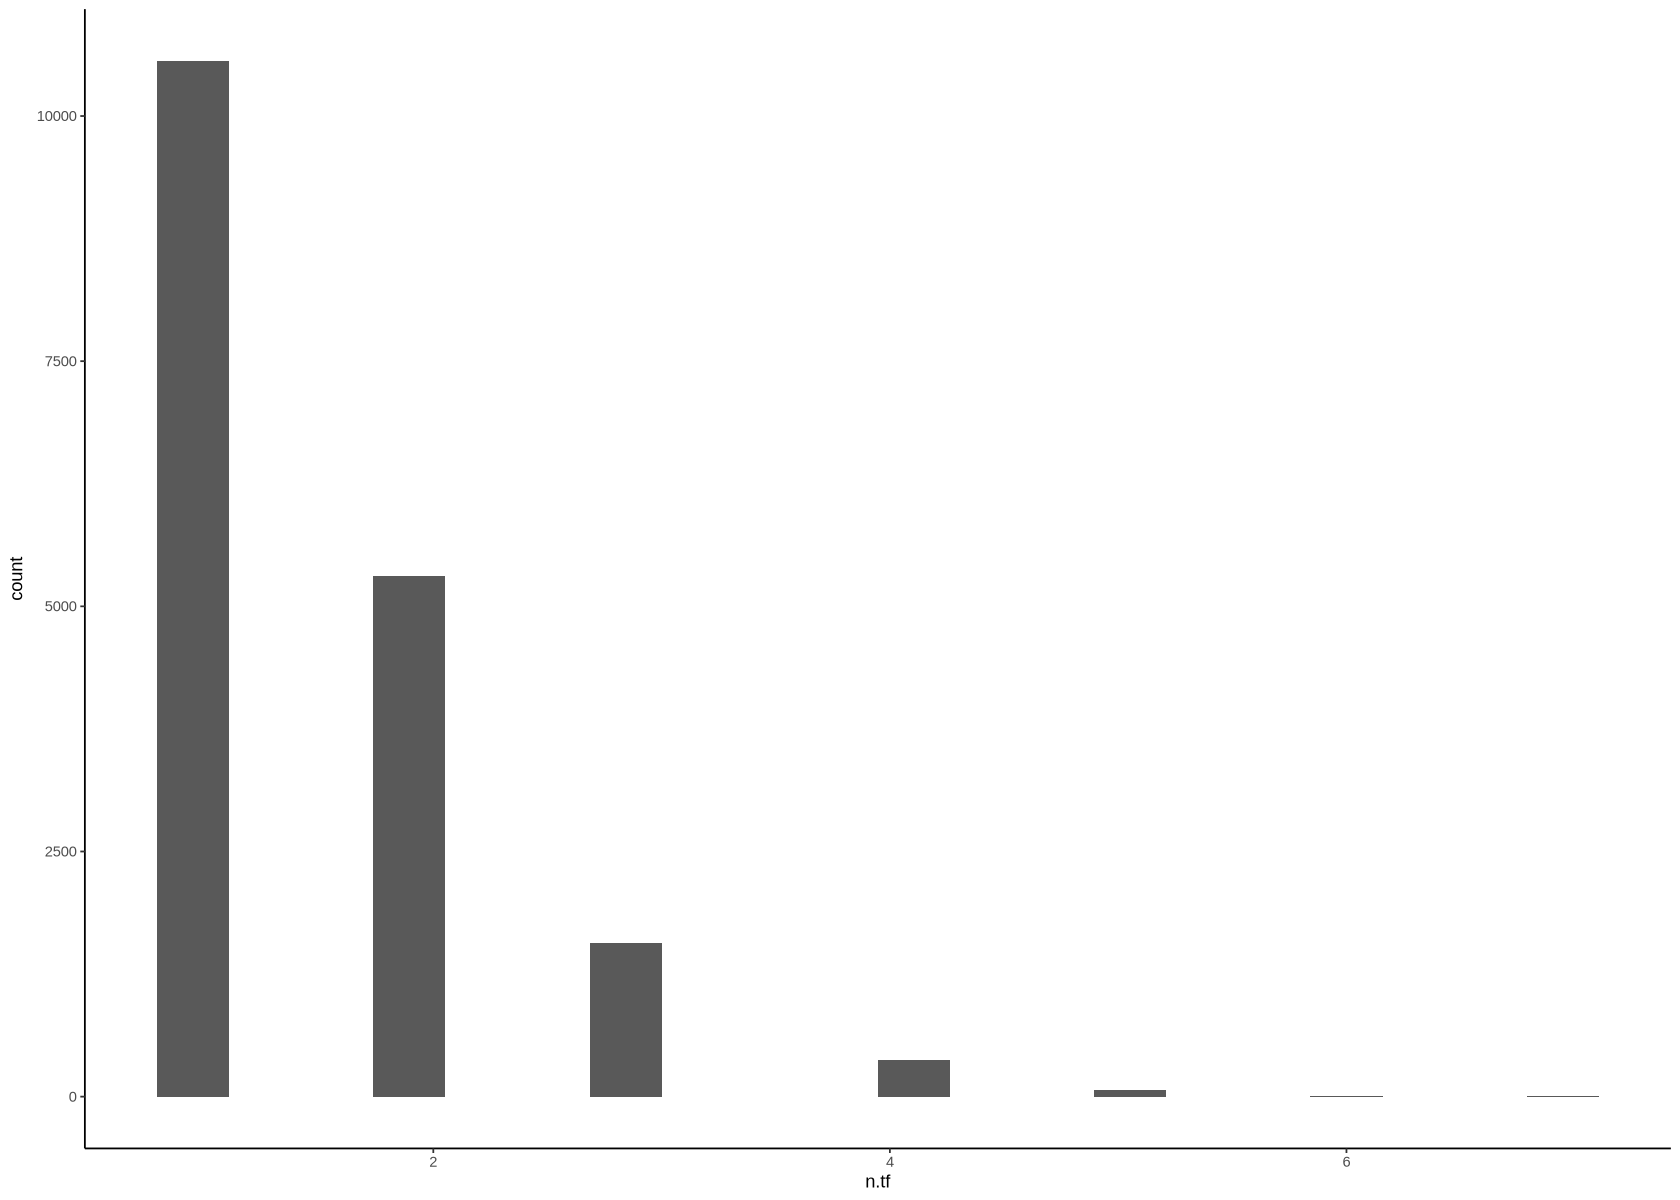

In [98]:
head(cell.tf.distribution)
ntf.df<- cell.tf.distribution %>% filter(hyperp.pcr.adj < 0.0005 & hyperp.umis.adj < 0.0005) %>% group_by(Cellbc) %>% summarize(n.tf = length(unique(Alignment)))
dim(ntf.df)
head(ntf.df)

ggplot(ntf.df, aes(x=n.tf))+
geom_histogram(bins = 20)+
theme_classic()

In [99]:

donor.info$sublib <- stri_split_fixed(donor.info$cell, pattern = "_", simplify = TRUE)[,2]
donor.info$Cellbc <- stri_split_fixed(donor.info$cell, pattern = "_", simplify = TRUE)[,1]

donor.filt <- donor.info %>% filter(sublib == "SS-PKR-624")

filt.tf.assign <- cell.tf.distribution %>% filter(hyperp.pcr < 0.0005 & hyperp.umis < 0.005) %>% group_by(Cellbc) %>% mutate(n.tf = length(unique(Alignment))) %>%
left_join(donor.filt)
head(filt.tf.assign)

Joining with `by = join_by(Cellbc)`


Alignment,Cellbc,n.UMIs,n.pcr.reads,n.umi.cell,n.pcr.cell,n.UMIs.total,n.PCR.total,non.tf.umis,non.tf.pcr,⋯,pvalue,FDR_pvalue,bestLikelihood,bestSample,median_likelihood,population_average_likelihood,donor1,donor2,donor3,sublib
<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ASCL2_TFORF3108_NM_005170.2,ACAGTGGTTTCAGCTCGAATCTGT,1,14,1,14,378,14336,65056,2427253,⋯,2.7677e-80,8.8600e-80,-43.041,donor2,-122.600,-42.261,-122.600,-43.041,-125.860,SS-PKR-624
ASCL2_TFORF3108_NM_005170.2,ACTTGATGGTGTGTCGGCCTGTTC,1,9,2,60,378,14336,65056,2427253,⋯,8.1890e-23,9.8326e-23,-43.465,donor1,-65.552,-28.152,-43.465,-83.415,-65.552,SS-PKR-624
ASCL2_TFORF3108_NM_005170.2,ACTTGATGTGCTGATAGTACATCT,2,73,6,198,378,14336,65056,2427253,⋯,2.4467e-107,1.4103e-106,-64.809,donor1,-171.420,-62.754,-64.809,-219.920,-171.420,SS-PKR-624
ASCL2_TFORF3108_NM_005170.2,ACTTGATGTTCTGTGTGTAAGGTG,1,4,3,23,378,14336,65056,2427253,⋯,4.2927e-102,2.2055e-101,-32.890,donor3,-134.430,-35.434,-134.430,-134.750,-32.890,SS-PKR-624
ASCL2_TFORF3108_NM_005170.2,ATCACGTTGCCTGTTCGATTCATC,2,96,2,96,378,14336,65056,2427253,⋯,2.7239e-142,3.3609e-141,-39.999,donor3,-181.560,-47.552,-196.490,-181.560,-39.999,SS-PKR-624
ASCL2_TFORF3108_NM_005170.2,ATCACGTTTAGCTTGTGACCTTAG,1,6,3,98,378,14336,65056,2427253,⋯,1.3383e-35,1.8903e-35,-53.215,donor2,-88.088,-30.682,-131.390,-53.215,-88.088,SS-PKR-624


In [100]:
ex.cell <- filt.tf.assign %>% 
#filter(n.tf >1) %>% 
filter(!is.na(bestSample))%>%
  group_by(Cellbc, bestSample,n.tf) %>%
  arrange(Alignment, .by_group = TRUE) %>%
  summarize(final.tf = paste0(Alignment, collapse = "+"), .groups = "drop") %>%
group_by(n.tf, final.tf) %>%
mutate(population.frequency = n())%>%
group_by(bestSample, n.tf, final.tf, population.frequency) %>%
summarize(donor.frequency = n()) %>%
group_by(final.tf) %>% 
arrange(-donor.frequency)%>%
slice_head()%>%
mutate(percent.top.donor = donor.frequency/population.frequency)


`summarise()` has grouped output by 'bestSample', 'n.tf', 'final.tf'. You can
override using the `.groups` argument.


Warning message:
“Removed 8 rows containing missing values or values outside the scale range
(`geom_bar()`).”


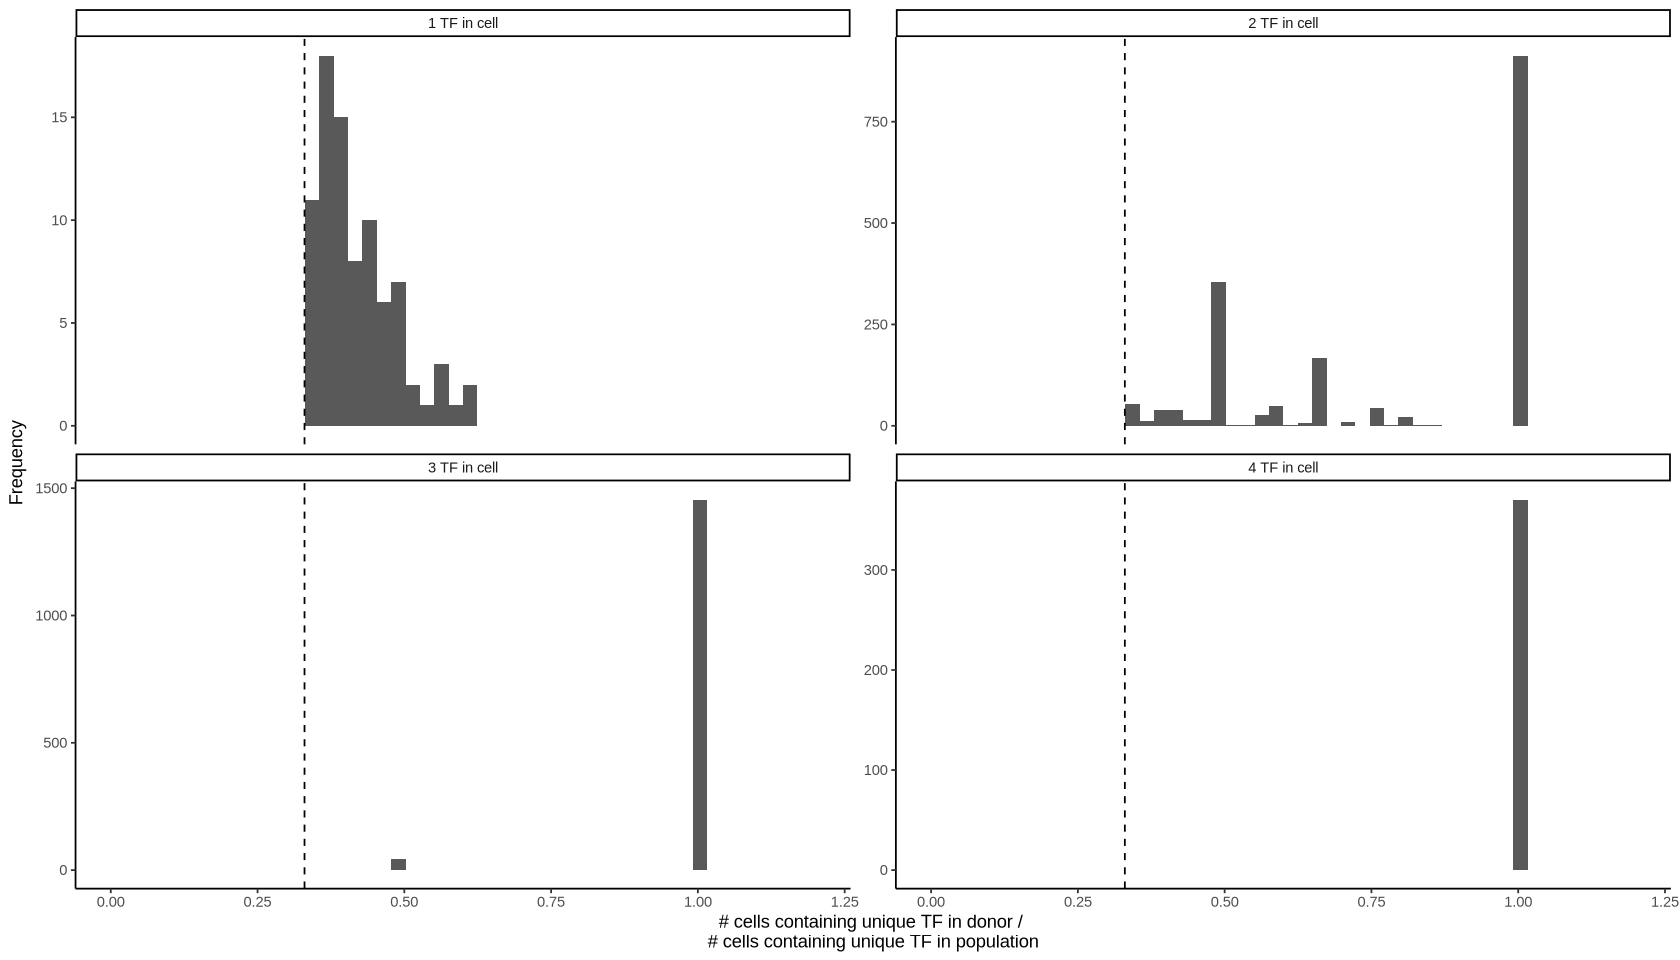

In [101]:
options(repr.plot.width = 14, repr.plot.height = 8)

ex.cell %>%
mutate(n.tf = paste0(n.tf, " TF in cell"))%>%
filter(n.tf < 5) %>% 
ggplot(aes(x=percent.top.donor))+
geom_histogram(bins=50)+
theme_classic()+
xlim(0,1.2)+
facet_wrap(~n.tf, scale = "free_y")+
geom_vline(xintercept = 0.33, linetype = "dashed")+
xlab("# cells containing unique TF in donor / \n # cells containing unique TF in population ")+
ylab("Frequency")

In [177]:
moi <- 0.2
starting.cells <- 100000
n.tfs <- 84
n.infections <- round(starting.cells * moi)
n.donor <- 3

model <- lapply(1:n.donor, function(x){
    set.seed(123+x)
    df <- data.frame(cellid = sample(starting.cells, n.infections, replace = TRUE),
                 tfid = sample(n.tfs, n.infections, replace = TRUE)) %>%
    group_by(cellid) %>% 
    arrange(tfid,.by_group = TRUE)%>%
    summarize(n.tf = n(),
          final.tf = paste0(tfid, collapse = "+"), .groups = "drop")
    df$donor <- paste0("donor", x)
    return(df)

})

In [178]:
model <- do.call(rbind, model)

`summarise()` has grouped output by 'donor', 'n.tf', 'final.tf'. You can
override using the `.groups` argument.
Warning message:
“Removed 8 rows containing missing values or values outside the scale range
(`geom_bar()`).”


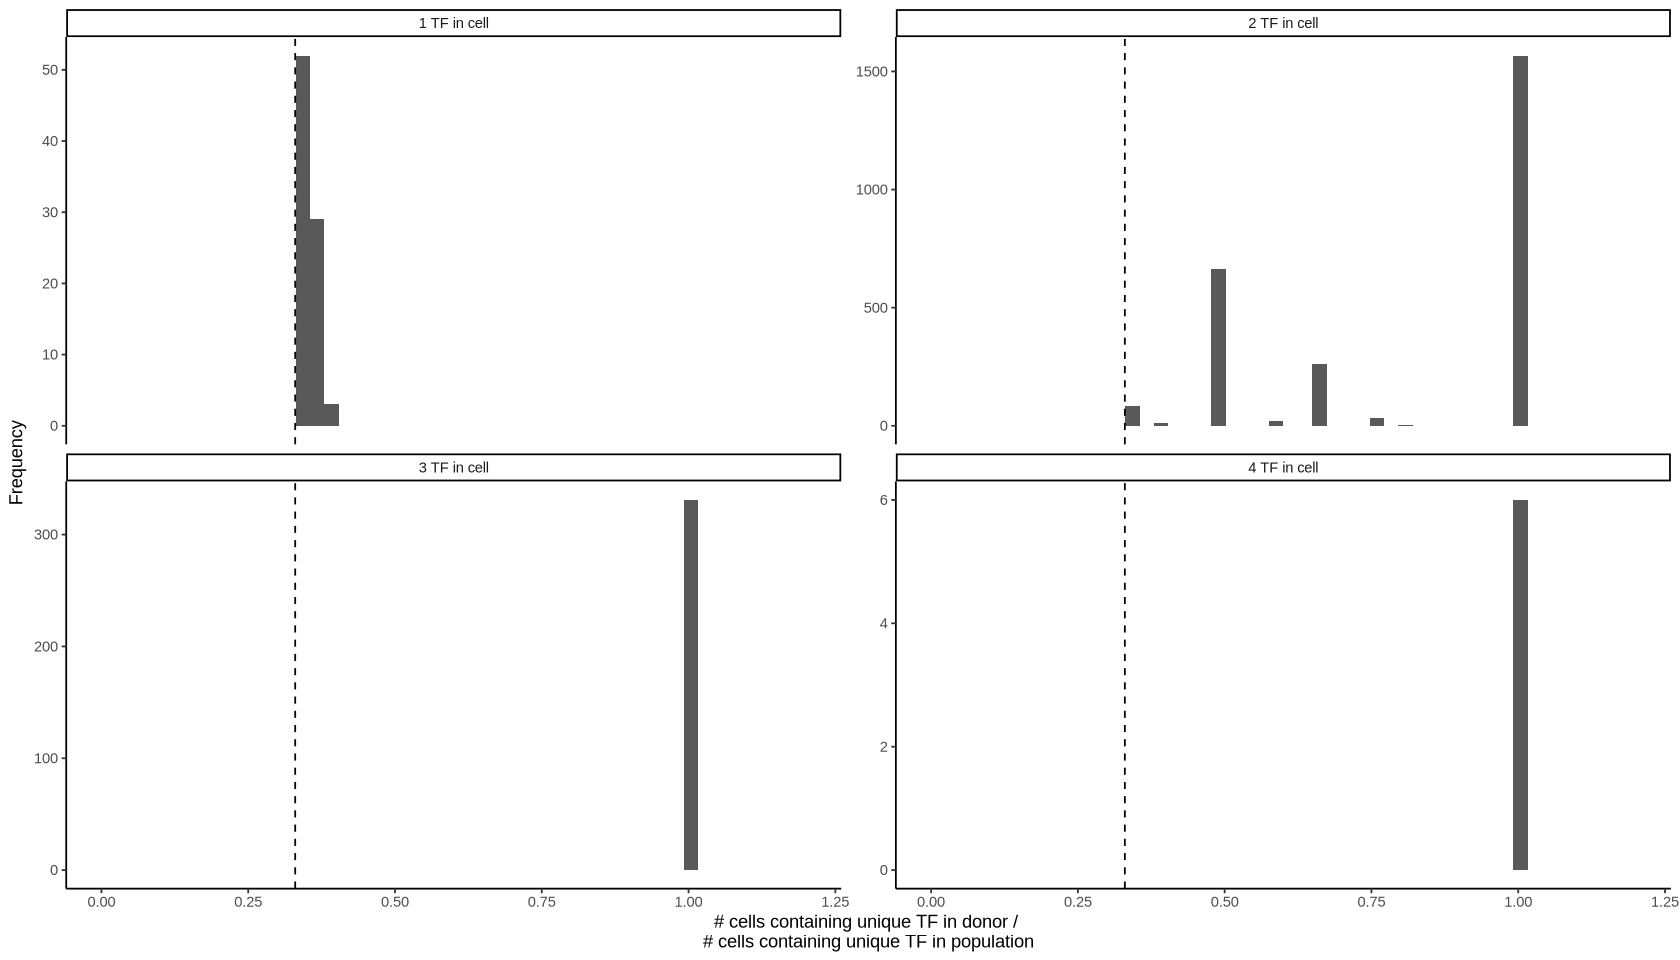

In [181]:
model %>%
mutate(n.tf = paste0(n.tf, " TF in cell"))%>%
group_by(n.tf, final.tf) %>%
mutate(population.frequency = n())%>%
group_by(donor, n.tf, final.tf, population.frequency) %>%
summarize(donor.frequency = n()) %>%
group_by(final.tf) %>% 
arrange(-donor.frequency)%>%
slice_head()%>%
mutate(percent.top.donor = donor.frequency/population.frequency) %>%
ggplot(aes(x=percent.top.donor))+
geom_histogram(bins=50)+
theme_classic()+
xlim(0,1.2)+
facet_wrap(~n.tf, scale = "free_y")+
geom_vline(xintercept = 0.33, linetype = "dashed")+
xlab("# cells containing unique TF in donor / \n # cells containing unique TF in population ")+
ylab("Frequency")